In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from fim import apriori

In [3]:
# open the files
mca_df = pd.read_csv('../data/auxiliary/mca_ai_measurements.csv')

with open('../data/tesda/nc_course_codes_mapping.json') as file:
    nc_course_codes_mapping = json.load(file)

with open('../data/tesda/tr_code_desc_mapping.json') as file:
    tr_code_desc_mapping = json.load(file)

In [4]:
median_aioe = mca_df['AIOE'].median()
median_comple = mca_df['Complementarity'].median()

def classify_by_ai_risk(job, threshold_aioe=median_aioe, threshold_comple=median_comple):
    job_aioe, job_comple = job['AIOE'], job['Complementarity']
    if job_aioe < threshold_aioe:
        return 'Not Affected'
    elif job_comple < threshold_comple:
        return 'Automated'
    else:
        return 'Augmented'

mca_df['AI Risk Classification'] = mca_df.apply(classify_by_ai_risk, axis=1)

In [5]:
mca_df['Core Competencies'] = mca_df['Educational Qualification'].map(nc_course_codes_mapping)
is_tesda = ~mca_df['Educational Qualification'].map(nc_course_codes_mapping).isnull()
tesda_df = mca_df[is_tesda].copy()

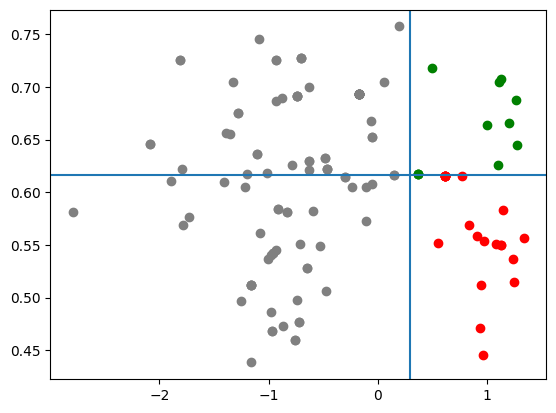

In [6]:
is_not_affected = tesda_df['AI Risk Classification'] == 'Not Affected'
is_automated = tesda_df['AI Risk Classification'] == 'Automated'
is_augmented = tesda_df['AI Risk Classification'] == 'Augmented'

plt.scatter(tesda_df[is_not_affected].AIOE, tesda_df[is_not_affected].Complementarity, color='gray',)
plt.scatter(tesda_df[is_automated].AIOE, tesda_df[is_automated].Complementarity, color='red',)
plt.scatter(tesda_df[is_augmented].AIOE, tesda_df[is_augmented].Complementarity, color='green',)

plt.axvline(median_aioe)
plt.axhline(median_comple)

plt.show()

In [7]:
itemsets = apriori(
    tesda_df['Core Competencies'].apply(lambda core_competencies : [
        tr_code_desc_mapping[core_competency] for core_competency in core_competencies
    ]),
    supp=5,
    zmin=2,
    #report='S'
)
itemsets = sorted(itemsets, key=lambda x: x[1], reverse=True)

In [13]:
itemsets[-7]

(('Perform Computer Operations',
  'Apply quality standards',
  'Practice occupational health and safety procedures',
  'Work in a team environment',
  'Participate in workplace communication'),
 7)

In [19]:
itemsets = apriori(
    tesda_df.loc[is_augmented, 'Core Competencies'].apply(lambda core_competencies : [
        tr_code_desc_mapping[core_competency] for core_competency in core_competencies
    ]),
    supp=5,
    zmin=2,
    #report='S'
)
itemsets = sorted(itemsets, key=lambda x: x[1], reverse=True)
itemsets

[(('Work in a team environment', 'Participate in workplace communication'), 8),
 (('Practice occupational health and safety procedures',
   'Practice career professionalism',
   'Work in a team environment',
   'Participate in workplace communication'),
  6),
 (('Practice occupational health and safety procedures',
   'Practice career professionalism',
   'Work in a team environment'),
  6),
 (('Practice occupational health and safety procedures',
   'Practice career professionalism',
   'Participate in workplace communication'),
  6),
 (('Practice occupational health and safety procedures',
   'Practice career professionalism'),
  6),
 (('Practice occupational health and safety procedures',
   'Work in a team environment',
   'Participate in workplace communication'),
  6),
 (('Practice occupational health and safety procedures',
   'Work in a team environment'),
  6),
 (('Practice occupational health and safety procedures',
   'Participate in workplace communication'),
  6),
 (('Prac